Universidad del Valle de Guatemala  
Departamento de Ciencias de la Computación  
CC2017 - Modelación y Simulación - sección 10

Cristian Túnchez (231359)  
Nadissa Vela (23764)  
Javier Linares (231135)  
Ernesto Ascencio (23009)

# **Colapso Hospitalario de Ciudad UVG (post-intercambio)**

El Grupo 1 entregó su proyección de desplazados que requieren atención médica. Este cuaderno la incorpora al modelo y responde dos preguntas:

1. ¿Cuántas muertes evitables adicionales se producen en las primeras 48 horas respecto al escenario base?
2. ¿Qué intervención reduciría más esa cifra?

El escenario base es el del cuaderno `SistemaHospitalario(Antes)`: la ciudad con los heridos que nuestro grupo proyectó, sin desplazados y sin intervención. Aquí se reutiliza su resultado desde el cache para que la comparación sea contra el mismo escenario.

Todo el modelo vive en `src/hospital`. Aquí solo se llama y se grafica.

## ¿Qué cambia respecto al cuaderno anterior?

Las siete reglas del modelo (R1 a R7) son las mismas. Lo único que cambia es que ahora entran heridos adicionales: **9100 desplazados** sobre los 11,773 del escenario base, un 77% más de demanda.

El Grupo 1 entregó su tabla en un formato distinto al que consume el modelo, así que se le aplicaron conversiones para construir `data/intercambio/grupo1_demanda.csv`.

### Supuestos de esta incorporación

- **La demanda es aditiva.** Los desplazados se suman a nuestros heridos.

- **El triage se reparte con nuestras proporciones.** El Grupo 1 da totales por zona sin separar gravedad. Se usan las proporciones leve/moderado/grave de nuestra propia estimación inicial de esa misma zona.

- **Cada bloque entra repartido por hora.** El bloque 0 del Grupo 1 concentra 6 095 personas. En lugar de hacerlas llegar todas en el mismo instante, el lote de cada bloque se divide en seis llegadas horarias, igual que los heridos del escenario base llegan de forma gradual.

In [1]:
# El cuaderno solo importa del paquete del modelo
import sys
from pathlib import Path

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))

import pandas as pd
from hospital import intercambio, montecarlo, outputs, params, plots

N_REP = 30          # réplicas de Monte Carlo
PROCESOS = None     # None = usar todos los núcleos disponibles
USAR_CACHE = True   # False obliga a recalcular aunque exista el cache
SUB_LOTES = 6       # el lote de cada bloque de 6 h se reparte en 6 llegadas horarias

pd.set_option("display.width", 160)

In [2]:
# La demanda del Grupo 1, ya convertida a nuestro esquema.
p = params.cargar()
demanda = intercambio.cargar_demanda_grupo1()

print(demanda.head(5).to_string(index=False))
print(f"\nFilas: {len(demanda)}   Heridos adicionales: "
      f"{demanda[['heridos_leves', 'heridos_moderados', 'heridos_graves']].values.sum()}")
print()
print(intercambio.resumen_impacto(p, demanda).to_string(index=False))

zona  bloque  heridos_leves  heridos_moderados  heridos_graves
  Z1       1           1423                446             160
  Z2       1            316                 98              27
  Z3       1            560                190              70
  Z4       1            148                 43              13
  Z5       1           1821                558             222

Filas: 60   Heridos adicionales: 9100

zona  base_total  grupo1_total  nuevo_total  incremento_pct
  Z1        4050          2765         6815            68.3
  Z2         948           812         1760            85.7
  Z3        1640          1306         2946            79.6
  Z4         565           368          933            65.1
  Z5        4570          3849         8419            84.2


In [3]:
# R1: los heridos del Grupo 1 entran como llegadas adicionales al sistema.
lotes = intercambio.aplicar_demanda(p, demanda, sub_lotes=SUB_LOTES)

por_bloque = pd.DataFrame([{"bloque": int(l.t // params.BLOQUE_H) + 1, "heridos": l.total}
                           for l in lotes]).groupby("bloque")["heridos"].sum()

print(f"{len(lotes)} lotes de llegada, {sum(l.total for l in lotes)} heridos en total")
print(f"Entran entre la hora {min(l.t for l in lotes):.0f} y la hora {max(l.t for l in lotes):.0f}")
print()
print("Heridos adicionales por bloque:")
print(por_bloque.to_string())

206 lotes de llegada, 9100 heridos en total
Entran entre la hora 0 y la hora 48

Heridos adicionales por bloque:
bloque
1    6095
2    1197
3     791
4     554
5     270
6     135
7      44
8      10
9       4


## Paso 1: los dos escenarios

Se comparan dos escenarios que solo se diferencian en la demanda del Grupo 1. Ambos usan las **mismas semillas**, así que (por ejemplo) la réplica 7 de uno tiene la misma aleatoriedad que la réplica 7 del otro. Eso permite comparar réplica contra réplica y detectar la diferencia con 30 corridas en lugar de cientos.

El escenario base sale del cache que dejó el cuaderno anterior; es el mismo objeto, no una corrida nueva.

In [4]:
# Escenario base: el del cuaderno anterior, sin desplazados. Sale del cache.
base = montecarlo.cargar_o_correr(
    "base",
    lambda: montecarlo.correr_replicas(p, n=N_REP, procesos=PROCESOS),
    usar_cache=USAR_CACHE, firma=N_REP,
)

# Escenario con Grupo 1: las mismas reglas R1-R7, más los heridos desplazados.
con_g1 = montecarlo.cargar_o_correr(
    "grupo1",
    lambda: montecarlo.correr_replicas(p, n=N_REP, procesos=PROCESOS,
                                       etiqueta="con Grupo 1", llegadas_extra=lotes),
    usar_cache=USAR_CACHE, firma=(N_REP, SUB_LOTES, sum(l.total for l in lotes)),
)

resumen = pd.DataFrame([
    {"escenario": "base", "heridos que llegan": base.generados.mean(),
     "muertes evitables": base.muertes_evitables.mean(),
     "mortalidad evitable %": 100 * base.tasa_evitable.mean()},
    {"escenario": "con Grupo 1", "heridos que llegan": con_g1.generados.mean(),
     "muertes evitables": con_g1.muertes_evitables.mean(),
     "mortalidad evitable %": 100 * con_g1.tasa_evitable.mean()},
])
print(resumen.round(1).to_string(index=False))
print(f"\nMismas semillas en los dos escenarios: "
      f"{base.metadatos['semillas'] == con_g1.metadatos['semillas']}")

  escenario  heridos que llegan  muertes evitables  mortalidad evitable %
       base             11312.9             2786.8                   24.5
con Grupo 1             20412.9             7913.3                   38.7

Mismas semillas en los dos escenarios: True


## Resultado 1: muertes evitables adicionales

Se evalúan las primeras 48 horas, es decir los primeros 8 bloques. La diferencia se calcula réplica contra réplica y se reporta con su intervalo de confianza del 95%.

In [ ]:
# Pregunta 2 (primera parte): ¿cuántas muertes evitables adicionales?
comparacion = montecarlo.comparar_con_grupo1(base, con_g1, horas=48.0)
print(comparacion.round(1).to_string(index=False))

fila = comparacion.iloc[0]
print(
    f"\nRESPUESTA: incorporar la demanda del Grupo 1 produce "
    f"{fila['adicionales_media']:.0f} muertes evitables adicionales "
    f"(IC 95 %: {fila['adicionales_ic95_bajo']:.0f}–{fila['adicionales_ic95_alto']:.0f}) "
    f"en las primeras 48 horas: se pasa de {fila['base_media']:.0f} a "
    f"{fila['con_grupo1_media']:.0f}, un aumento del {fila['incremento_pct']:.0f} %."
)

       ventana  n_replicas  base_media  base_ic95_bajo  base_ic95_alto  con_grupo1_media  con_grupo1_ic95_bajo  con_grupo1_ic95_alto  adicionales_media  adicionales_ic95_bajo  adicionales_ic95_alto  incremento_pct metodo_ic
 primeras 48 h          30      2758.6          2577.9          2939.3            7047.0                6783.9                7310.1             4288.3                 4142.0                 4434.7           155.5         t
72 h completas          30      2786.8          2600.7          2972.9            7913.3                7604.8                8221.8             5126.5                 4974.3                 5278.7           184.0         t

RESPUESTA: incorporar la demanda del Grupo 1 produce 4288 muertes evitables adicionales (IC 95 %: 4142–4435) en las primeras 48 horas: se pasa de 2759 a 7047, un aumento del 155 %.


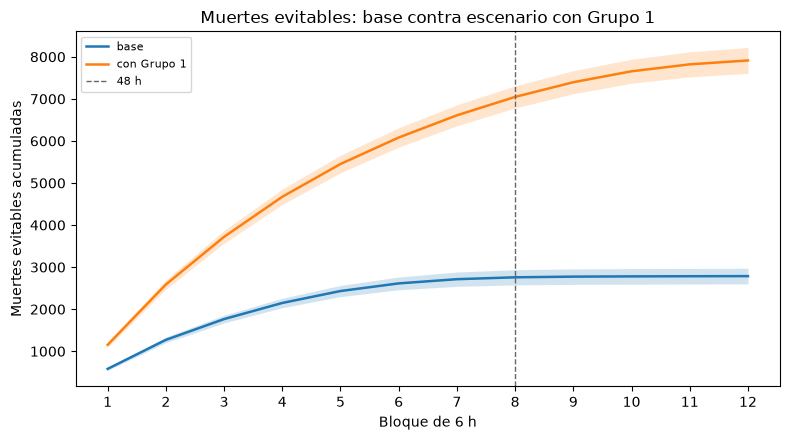

In [6]:
# R6: cuándo se producen esas muertes. Se comparan las curvas acumuladas de los dos escenarios.
import matplotlib.pyplot as plt

plots.DIR_FIGURAS.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 4.5))
for etiqueta, res in (("base", base), ("con Grupo 1", con_g1)):
    m = montecarlo.muertes_por_bloque(res, acumulado=True)
    m = m[m["tipo"] == "evitable"].sort_values("bloque")
    plots.serie_con_banda(ax, m["bloque"], m["muertes_media"],
                          m["ic95_bajo"], m["ic95_alto"], label=etiqueta)
ax.axvline(8, color="0.4", linestyle="--", linewidth=1, label="48 h")
ax.set_xlabel("Bloque de 6 h")
ax.set_ylabel("Muertes evitables acumuladas")
ax.set_title("Muertes evitables: base contra escenario con Grupo 1")
ax.set_xticks(range(1, 13))
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(plots.DIR_FIGURAS / "muertes_base_vs_g1.png", dpi=130)

## Resultado 2: dónde se colapsa el sistema

Con el doble de demanda conviene revisar si el cuello de botella sigue siendo el mismo o si se desplaza a otro recurso.

           instalacion      recurso  bloque_colapso  ocupacion_media  cola_media  ic95_bajo  ic95_alto
  Hospital General UVG       medico               2         1.000000 5455.343056        1.0        1.0
Hospital Regional Este       medico               2         1.000000 3800.670833        1.0        1.0
       Puesto Salud Z5       medico               2         1.000000  499.402778        1.0        1.0
            Clínica Z2 cama_general            <NA>         0.474167  301.850000        NaN        NaN
            Clínica Z2     cama_uci            <NA>         0.250000   47.920833        NaN        NaN
            Clínica Z2       medico            <NA>         1.000000 1833.720833        NaN        NaN
            Clínica Z2    quirofano            <NA>         1.000000   47.920833        NaN        NaN
  Hospital General UVG cama_general            <NA>         0.441667  775.708333        NaN        NaN

Con la demanda del Grupo 1, la primera en colapsar es Puesto Salud Z5 po

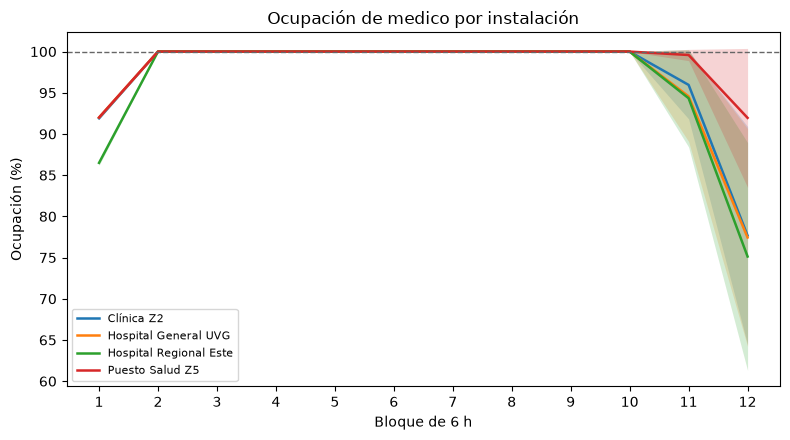

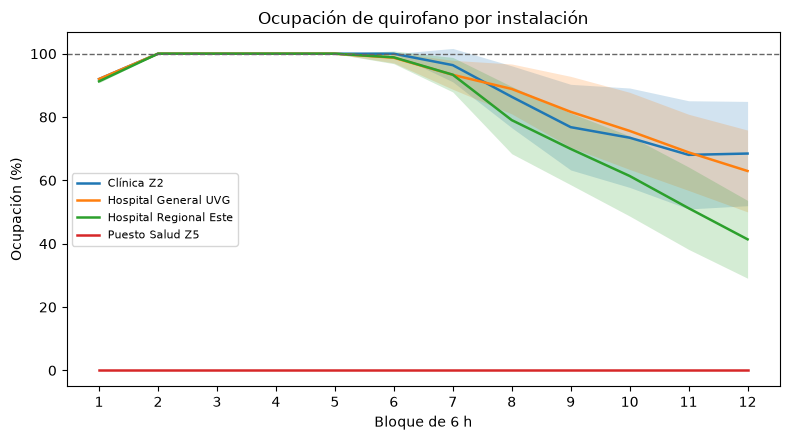

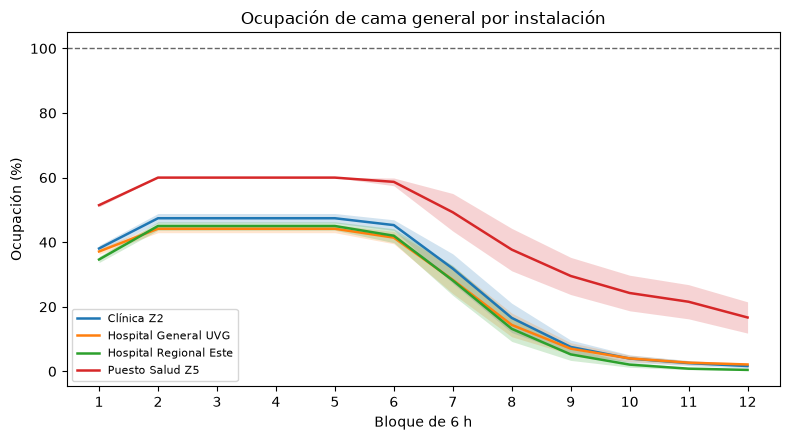

In [7]:
# R2, R3 y R4: ocupación y colapso con la demanda del Grupo 1.
bloques_g1 = montecarlo.resumen_bloques(con_g1)
for recurso in ("medico", "quirofano", "cama_general"):
    plots.ocupacion_por_bloque(bloques_g1, recurso=recurso,
                               nombre=f"ocupacion_{recurso}_g1.png")

print(montecarlo.bloque_de_colapso(con_g1, df_bloques=bloques_g1).head(8).to_string(index=False))

r = montecarlo.primer_colapso(con_g1)
print(
    f"\nCon la demanda del Grupo 1, la primera en colapsar es {r['instalacion']} "
    f"por falta de {r['recurso']}, en el bloque {r['bloque']} "
    f"(horas {(r['bloque'] - 1) * 6}–{r['bloque'] * 6}), "
    f"con {100 * r['ocupacion']:.0f} % de ocupación y {r['cola']:.0f} pacientes en cola."
)

Cola máxima de graves: 274 en el base, 543 con Grupo 1
Cola máxima de moderados: 807 en el base, 1968 con Grupo 1
Cola máxima de leves: 5894 en el base, 11234 con Grupo 1


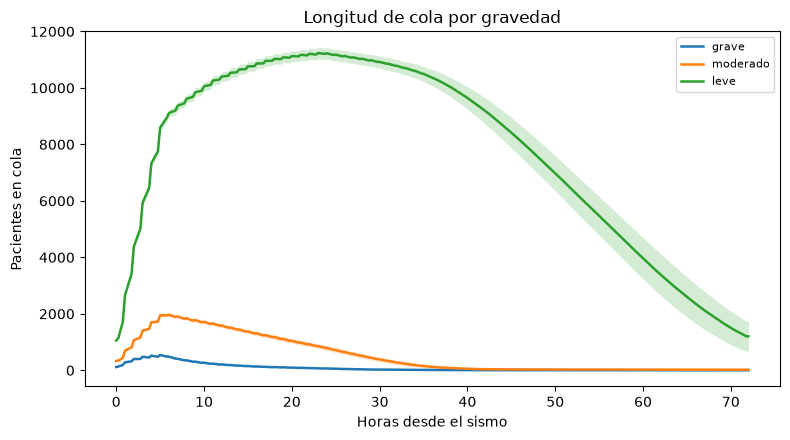

In [8]:
# R4: la cola por gravedad crece mucho más que en el escenario base.
plots.cola_por_triage(montecarlo.cola_por_triage(con_g1), nombre="cola_por_triage_g1.png")

picos = montecarlo.cola_por_triage(con_g1).groupby("triage")["cola_media"].max()
picos_base = montecarlo.cola_por_triage(base).groupby("triage")["cola_media"].max()
for triage in ("grave", "moderado", "leve"):
    print(f"Cola máxima de {triage}s: {picos_base[triage]:.0f} en el base, "
          f"{picos[triage]:.0f} con Grupo 1")

## Resultado 3: qué intervención reduce más esas muertes

Se relaja cada recurso un 20% **sobre el escenario que ya incluye a los desplazados**, y se mide cuánto recorta las muertes evitables de las primeras 48 horas. Todos los escenarios comparten semillas, así que la comparación sigue siendo pareada.

      escenario  muertes_evitables_media  dif_pareada_media  dif_ic95_bajo  dif_ic95_alto  reduccion_pct  determinante
           base                   7047.0                0.0            0.0            0.0            0.0         False
     +20% camas                   7047.0                0.0            0.0            0.0            0.0         False
       +20% uci                   7047.0                0.0            0.0            0.0            0.0         False
+20% quirofanos                   7056.0               -9.1          -36.5           18.4           -0.1         False
   +20% medicos                   6697.1              349.9          313.4          386.4            5.0          True
    +20% sangre                   7047.0                0.0            0.0            0.0            0.0         False

RESPUESTA: la intervención que más reduce las muertes evitables de las primeras 48 h es aumentar medicos un 20 %: evita 350 muertes (IC 95 %: 313–386), un 5.0 % menos

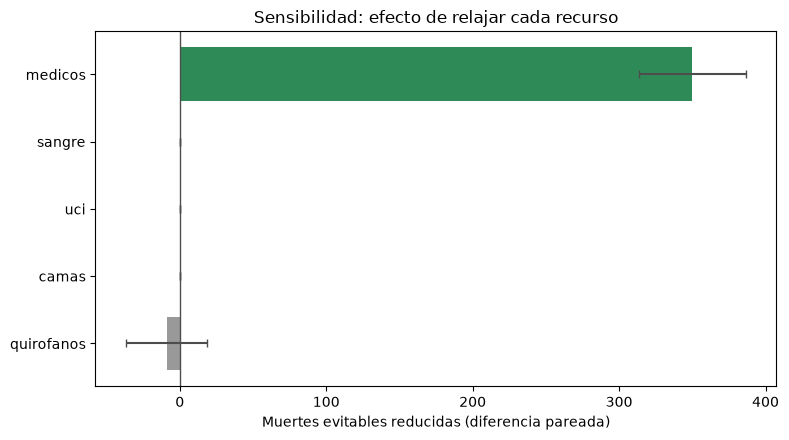

In [ ]:
# Pregunta 2 (segunda parte): la intervención que más reduce esas muertes.
sens_g1 = montecarlo.cargar_o_correr(
    "sensibilidad20_grupo1",
    lambda: montecarlo.sensibilidad_recursos(
        p, n=N_REP, delta=0.20, procesos=PROCESOS,
        llegadas_extra=lotes, metrica="muertes_evitables_48h"),
    usar_cache=USAR_CACHE, firma=(N_REP, 0.20, SUB_LOTES),
)
plots.sensibilidad(sens_g1, nombre="sensibilidad_g1.png")

columnas = ["escenario", "muertes_evitables_media", "dif_pareada_media",
            "dif_ic95_bajo", "dif_ic95_alto", "reduccion_pct", "determinante"]
print(sens_g1[columnas].round(1).to_string(index=False))

ganador = sens_g1[sens_g1["determinante"]]
if len(ganador):
    fila = ganador.iloc[0]
    print(
        f"\nRESPUESTA: la intervención que más reduce las muertes evitables de las primeras "
        f"48 h es aumentar {fila['recurso']} un 20 %: evita {fila['dif_pareada_media']:.0f} "
        f"muertes (IC 95 %: {fila['dif_ic95_bajo']:.0f}–{fila['dif_ic95_alto']:.0f}), "
        f"un {fila['reduccion_pct']:.1f} % menos."
    )
else:
    print("\nNinguna intervención muestra un efecto distinguible de cero.")

## Límitaciones de la Simulación

- La demanda del Grupo 1 se trata como **aditiva**. Si hubiera traslape con nuestros propios heridos, las muertes adicionales serían menos.

- El **reparto por gravedad** de los desplazados usa nuestras proporciones, no un dato del Grupo 1.

- Al igual que en la primera simulación (pre-intercambio), las distancias entre zonas, las ventanas de supervivencia y el consumo de insumos por procedimiento son supuestos propios, declarados en el bloque S-1 a S-7 de `params.py`.